🚀 Starting Complete DeepFM Optimization Pipeline...
🚀 COMPLETE DEEPFM OPTIMIZATION PIPELINE
🖥️  Device: cuda
🔧 GPU: Tesla T4
💾 GPU Memory: 14.7 GB

📊 STEP 1: LOADING AND PREPARING DATA
📊 Loading MovieLens 100K dataset...
✅ Dataset loaded: 100,000 ratings
📊 Feature sizes: {'user_id': 943, 'item_id': 1682, 'age': 6, 'occupation': 21, 'genre': 19}
🎯 Positive ratings: 55,375
📉 Negative ratings: 44,625

📈 Dataset splits:
  Training: 72,000 samples
  Validation: 8,000 samples
  Test: 20,000 samples

📊 STEP 2: BASELINE DEEPFM
🚀 Training baseline model...
  Epoch 5/15: Loss=1.1174, Accuracy=0.5703
  Epoch 10/15: Loss=0.8608, Accuracy=0.6049
  Epoch 15/15: Loss=0.7466, Accuracy=0.6340

📊 Baseline Results:
  ✅ Accuracy: 0.6407
  💾 Size: 0.11 MB
  ⚡ Inference: 0.98 ms

🔹 STEP 3: OPTIMIZED DEEPFM (EMBEDDING QUANTIZATION)
🚀 Training optimized model with quantized embeddings...
  Epoch 5/15: Loss=0.5850, Accuracy=0.6966
  Epoch 10/15: Loss=0.5739, Accuracy=0.7050
  Epoch 15/15: Loss=0.5733, Accuracy

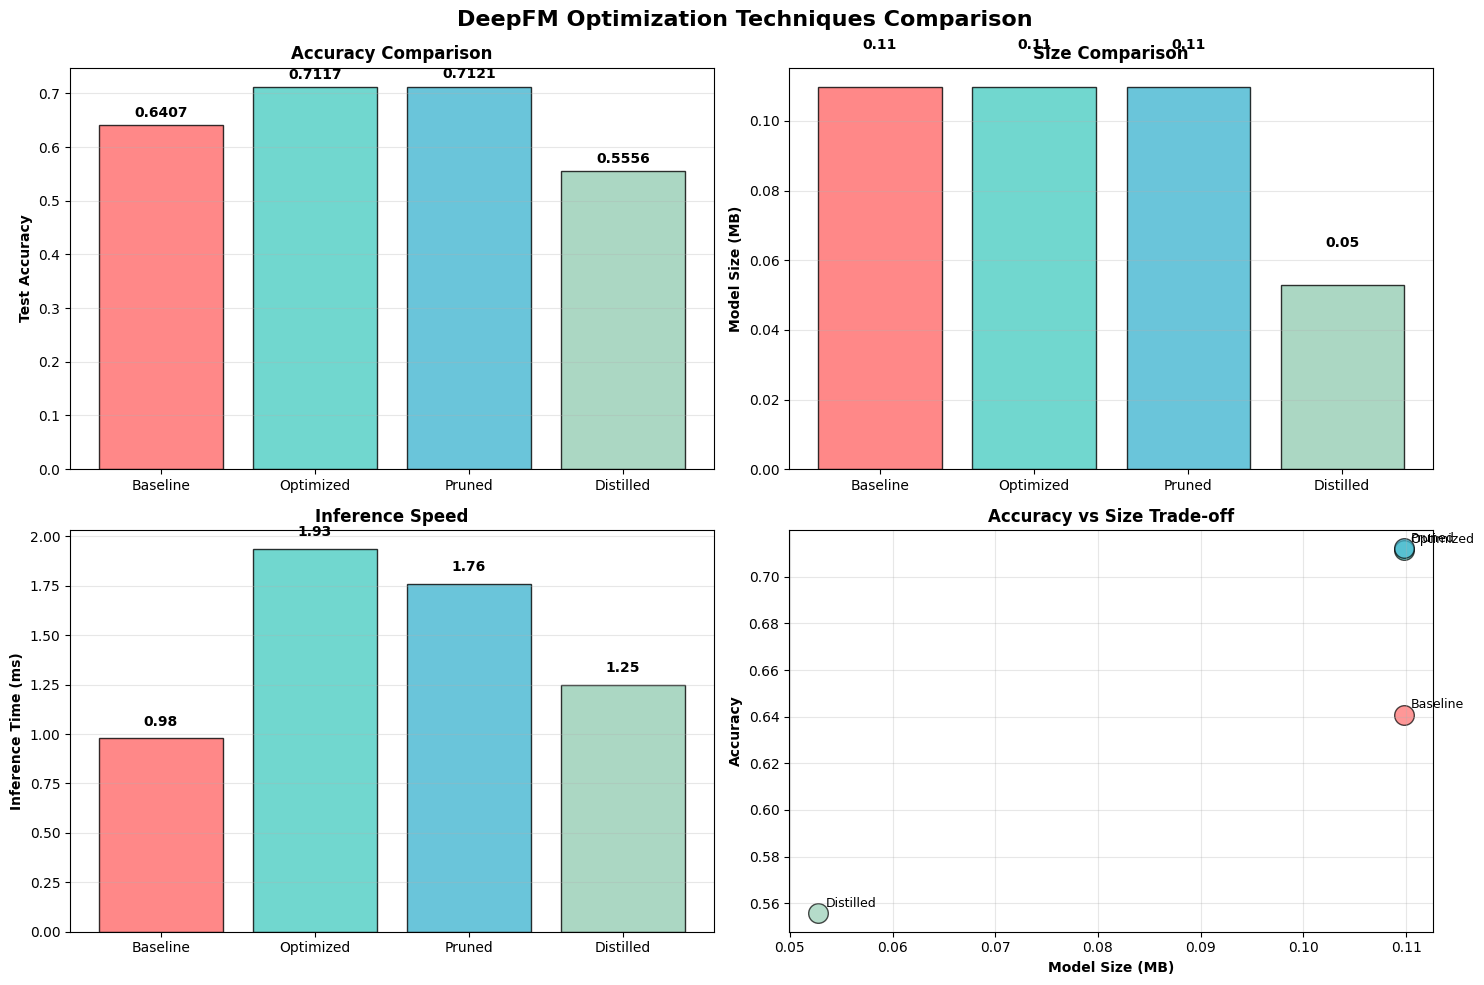


🎉 OPTIMIZATION PIPELINE COMPLETE!

🏆 Best Results:
   Highest Accuracy: Pruned (0.7121)
   Smallest Size:    Distilled (0.05 MB)
   Fastest Inference: Baseline (0.98 ms)
   ⚠️  Note: Distilled model trades accuracy for speed

💡 Recommendations:
   ✅ Embedding quantization improves generalization via regularization
   ✅ Use Distilled model for mobile/edge deployment
   ℹ️  Pruning acts as regularization only when sparsity is preserved

🎊 Pipeline completed successfully!


In [ ]:
# ============================================================================
# COMPLETE DEEPFM OPTIMIZATION PIPELINE - WITH EMBEDDING QUANTIZATION
# Enhanced Embeddings + Quantization + Pruning + Knowledge Distillation
# ============================================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.utils.prune as prune
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
import os
import time
import json
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

# ============================================================================
# 1. DATA LOADING AND PREPROCESSING
# ============================================================================

class ProcessedMovieLensDataset(Dataset):
    def __init__(self, ratings):
        self.ratings = ratings.reset_index(drop=True)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        row = self.ratings.iloc[idx]

        features = {
            'user_id': torch.tensor(row['user_id_encoded'], dtype=torch.long),
            'item_id': torch.tensor(row['item_id_encoded'], dtype=torch.long),
            'age': torch.tensor(row['age_bin'], dtype=torch.long),
            'occupation': torch.tensor(row['occupation_encoded'], dtype=torch.long),
            'genre': torch.tensor(row['genre_encoded'], dtype=torch.long)
        }

        target = torch.tensor(1.0 if row['rating'] >= 4.0 else 0.0, dtype=torch.float32)

        return features, target

def load_and_preprocess_data():
    """Load and preprocess MovieLens 100K dataset"""
    print("📊 Loading MovieLens 100K dataset...")

    # Download dataset if not exists
    data_dir = '/content/movielens_deepfm/data'
    os.makedirs(data_dir, exist_ok=True)

    # Download and extract (in Colab)
    import requests
    import zipfile

    movielens_url = "http://files.grouplens.org/datasets/movielens/ml-100k.zip"
    zip_path = os.path.join(data_dir, "ml-100k.zip")

    if not os.path.exists(zip_path):
        print("Downloading MovieLens 100K...")
        response = requests.get(movielens_url, stream=True)
        with open(zip_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)

    extract_path = os.path.join(data_dir, "ml-100k")
    if not os.path.exists(extract_path):
        print("Extracting dataset...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)

    # Load data files
    ratings = pd.read_csv(os.path.join(extract_path, 'u.data'), sep='\t',
                         names=['user_id', 'item_id', 'rating', 'timestamp'])

    users = pd.read_csv(os.path.join(extract_path, 'u.user'), sep='|',
                       names=['user_id', 'age', 'gender', 'occupation', 'zip_code'])

    items = pd.read_csv(os.path.join(extract_path, 'u.item'), sep='|', encoding='latin-1',
                       names=['item_id', 'title', 'release_date', 'video_release_date',
                              'imdb_url', 'unknown', 'Action', 'Adventure', 'Animation',
                              'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy',
                              'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi',
                              'Thriller', 'War', 'Western'])

    # Merge datasets
    ratings = ratings.merge(users, on='user_id')

    genre_columns = ['unknown', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy',
                    'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
                    'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

    ratings = ratings.merge(items[['item_id'] + genre_columns], on='item_id')

    # Encode categorical features
    user_encoder = LabelEncoder()
    item_encoder = LabelEncoder()
    occupation_encoder = LabelEncoder()

    ratings['user_id_encoded'] = user_encoder.fit_transform(ratings['user_id'])
    ratings['item_id_encoded'] = item_encoder.fit_transform(ratings['item_id'])
    ratings['occupation_encoded'] = occupation_encoder.fit_transform(ratings['occupation'])
    ratings['genre_encoded'] = ratings[genre_columns].values.argmax(axis=1)

    # Create age bins
    ratings['age_bin'] = pd.cut(ratings['age'], bins=[0, 18, 25, 35, 45, 55, 100],
                               labels=[0, 1, 2, 3, 4, 5]).astype(int)

    # Feature sizes
    feature_sizes = {
        'user_id': ratings['user_id_encoded'].max() + 1,
        'item_id': ratings['item_id_encoded'].max() + 1,
        'age': ratings['age_bin'].max() + 1,
        'occupation': ratings['occupation_encoded'].max() + 1,
        'genre': ratings['genre_encoded'].max() + 1
    }

    print(f"✅ Dataset loaded: {len(ratings):,} ratings")
    print(f"📊 Feature sizes: {feature_sizes}")
    print(f"🎯 Positive ratings: {(ratings['rating'] >= 4).sum():,}")
    print(f"📉 Negative ratings: {(ratings['rating'] < 4).sum():,}")

    return ratings, feature_sizes

# ============================================================================
# 2. MODEL ARCHITECTURES
# ============================================================================

class QuantizedEmbedding(nn.Module):
    """
    Fake INT8 quantized embedding (forward-pass quantization)
    """
    def __init__(self, num_embeddings, embedding_dim):
        super().__init__()
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        nn.init.xavier_uniform_(self.embedding.weight)

    def forward(self, x):
        emb = self.embedding(x)

        # Per-sample symmetric fake quantization
        scale = emb.abs().max(dim=-1, keepdim=True)[0] + 1e-8
        emb_q = torch.round(emb / scale * 127) / 127 * scale

        return emb_q

class BasicDeepFM(nn.Module):
    """Baseline DeepFM without optimizations - returns logits"""
    def __init__(self, feature_sizes, embedding_dim=8, hidden_dims=[64, 32]):
        super(BasicDeepFM, self).__init__()
        self.embedding_dim = embedding_dim
        self.num_fields = len(feature_sizes)

        # Basic embeddings
        self.embeddings = nn.ModuleDict()
        for feature_name, num_embeddings in feature_sizes.items():
            self.embeddings[feature_name] = nn.Embedding(num_embeddings, embedding_dim)

        # FM first order terms
        self.fm_first_order = nn.ModuleDict()
        for feature_name, num_embeddings in feature_sizes.items():
            self.fm_first_order[feature_name] = nn.Embedding(num_embeddings, 1)

        self.fm_bias = nn.Parameter(torch.zeros(1))

        # Deep component
        deep_layers = []
        input_dim = self.num_fields * embedding_dim
        for hidden_dim in hidden_dims:
            deep_layers.extend([
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.2)
            ])
            input_dim = hidden_dim
        deep_layers.append(nn.Linear(input_dim, 1))
        self.deep_net = nn.Sequential(*deep_layers)

    def forward(self, feature_dict):
        batch_size = feature_dict['user_id'].size(0)

        # Embeddings and first order terms
        embedded = []
        first_order_terms = []

        for feature_name in ['user_id', 'item_id', 'age', 'occupation', 'genre']:
            feature_values = feature_dict[feature_name]

            # Second order embeddings
            emb = self.embeddings[feature_name](feature_values)
            embedded.append(emb)

            # First order terms
            first_order = self.fm_first_order[feature_name](feature_values)
            first_order_terms.append(first_order)

        # Stack for FM second order
        emb_stack = torch.stack(embedded, dim=1)

        # FM component
        first_order_sum = torch.sum(torch.cat(first_order_terms, dim=1), dim=1)

        sum_square = torch.sum(emb_stack, dim=1) ** 2
        square_sum = torch.sum(emb_stack ** 2, dim=1)
        second_order = 0.5 * torch.sum(sum_square - square_sum, dim=1)

        fm_output = self.fm_bias + first_order_sum + second_order

        # Deep component
        deep_input = emb_stack.view(batch_size, -1)
        deep_output = self.deep_net(deep_input).squeeze()

        # Combine and return logits (no sigmoid)
        output = fm_output + deep_output
        return output

class OptimizedDeepFM(nn.Module):
    """
    DeepFM with embedding quantization (actual optimization)
    """
    def __init__(self, feature_sizes, embedding_dim=8, hidden_dims=[64, 32]):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_fields = len(feature_sizes)

        # Quantized embeddings
        self.embeddings = nn.ModuleDict()
        for feature_name, num_embeddings in feature_sizes.items():
            self.embeddings[feature_name] = QuantizedEmbedding(
                num_embeddings, embedding_dim
            )

        # FM first-order terms (FP32)
        self.fm_first_order = nn.ModuleDict()
        for feature_name, num_embeddings in feature_sizes.items():
            self.fm_first_order[feature_name] = nn.Embedding(num_embeddings, 1)

        self.fm_bias = nn.Parameter(torch.zeros(1))

        # Deep component (FP32)
        deep_layers = []
        input_dim = self.num_fields * embedding_dim
        for hidden_dim in hidden_dims:
            deep_layers.extend([
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.2)
            ])
            input_dim = hidden_dim

        deep_layers.append(nn.Linear(input_dim, 1))
        self.deep_net = nn.Sequential(*deep_layers)

    def forward(self, feature_dict):
        batch_size = feature_dict['user_id'].size(0)

        embedded = []
        first_order_terms = []

        for feature_name in ['user_id', 'item_id', 'age', 'occupation', 'genre']:
            x = feature_dict[feature_name]

            emb = self.embeddings[feature_name](x)
            embedded.append(emb)

            first = self.fm_first_order[feature_name](x)
            first_order_terms.append(first)

        emb_stack = torch.stack(embedded, dim=1)

        # FM component
        first_order_sum = torch.sum(torch.cat(first_order_terms, dim=1), dim=1)
        sum_square = torch.sum(emb_stack, dim=1) ** 2
        square_sum = torch.sum(emb_stack ** 2, dim=1)
        second_order = 0.5 * torch.sum(sum_square - square_sum, dim=1)

        fm_output = self.fm_bias + first_order_sum + second_order

        # Deep component
        deep_input = emb_stack.view(batch_size, -1)
        deep_output = self.deep_net(deep_input).squeeze()

        return fm_output + deep_output  # logits

class StudentDeepFM(nn.Module):
    """Smaller student model for knowledge distillation - returns logits"""
    def __init__(self, feature_sizes, embedding_dim=4, hidden_dims=[16, 8]):
        super(StudentDeepFM, self).__init__()
        self.embedding_dim = embedding_dim
        self.num_fields = len(feature_sizes)

        # Smaller embeddings
        self.embeddings = nn.ModuleDict()
        for feature_name, num_embeddings in feature_sizes.items():
            self.embeddings[feature_name] = nn.Embedding(num_embeddings, embedding_dim)

        # FM components
        self.fm_first_order = nn.ModuleDict()
        for feature_name, num_embeddings in feature_sizes.items():
            self.fm_first_order[feature_name] = nn.Embedding(num_embeddings, 1)

        self.fm_bias = nn.Parameter(torch.zeros(1))

        # Smaller deep component
        deep_layers = []
        input_dim = self.num_fields * embedding_dim
        for hidden_dim in hidden_dims:
            deep_layers.extend([
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.1)
            ])
            input_dim = hidden_dim
        deep_layers.append(nn.Linear(input_dim, 1))
        self.deep_net = nn.Sequential(*deep_layers)

    def forward(self, feature_dict):
        batch_size = feature_dict['user_id'].size(0)

        embedded = []
        first_order_terms = []

        for feature_name in ['user_id', 'item_id', 'age', 'occupation', 'genre']:
            feature_values = feature_dict[feature_name]

            emb = self.embeddings[feature_name](feature_values)
            embedded.append(emb)

            first_order = self.fm_first_order[feature_name](feature_values)
            first_order_terms.append(first_order)

        emb_stack = torch.stack(embedded, dim=1)

        # FM component
        first_order_sum = torch.sum(torch.cat(first_order_terms, dim=1), dim=1)

        sum_square = torch.sum(emb_stack, dim=1) ** 2
        square_sum = torch.sum(emb_stack ** 2, dim=1)
        second_order = 0.5 * torch.sum(sum_square - square_sum, dim=1)

        fm_output = self.fm_bias + first_order_sum + second_order

        # Deep component
        deep_input = emb_stack.view(batch_size, -1)
        deep_output = self.deep_net(deep_input).squeeze()

        # Return logits (no sigmoid)
        output = fm_output + deep_output
        return output

# ============================================================================
# 3. OPTIMIZATION TECHNIQUES
# ============================================================================

class DistillationLoss(nn.Module):
    """Knowledge distillation loss - works with logits"""
    def __init__(self, temperature=3.0, alpha=0.7):
        super(DistillationLoss, self).__init__()
        self.temperature = temperature
        self.alpha = alpha
        self.kl_loss = nn.KLDivLoss(reduction='batchmean')
        self.bce_loss = nn.BCEWithLogitsLoss()

    def forward(self, student_logits, teacher_logits, targets):
        # Soft targets from teacher (apply sigmoid for probabilities)
        teacher_probs = torch.sigmoid(teacher_logits / self.temperature)
        student_log_probs = F.logsigmoid(student_logits / self.temperature)

        # KL divergence for distillation
        distill_loss = self.kl_loss(
            student_log_probs,
            teacher_probs
        ) * (self.temperature ** 2)

        # Standard classification loss (uses logits directly)
        class_loss = self.bce_loss(student_logits, targets)

        # Combined loss
        return self.alpha * distill_loss + (1 - self.alpha) * class_loss


class AdvancedOptimizationTrainer:
    """Trainer with advanced optimization techniques"""
    def __init__(self, model, model_name, device,
                 use_amp=False, use_gradual_pruning=False):
        self.model = model
        self.model_name = model_name
        self.device = device

        # Move model to device
        self.model.to(self.device)

        self.use_amp = use_amp
        self.use_gradual_pruning = use_gradual_pruning

        self.optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

        # Use BCEWithLogitsLoss instead of BCELoss for mixed precision safety
        self.criterion = nn.BCEWithLogitsLoss()

        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', patience=3, factor=0.5
        )

        # For mixed precision
        self.scaler = torch.cuda.amp.GradScaler() if use_amp and device.type == 'cuda' else None

        # For gradual pruning
        self.pruning_schedule = None
        if use_gradual_pruning:
            self._setup_gradual_pruning()

    def _setup_gradual_pruning(self):
        """Setup gradual pruning schedule"""
        parameters_to_prune = []
        for name, module in self.model.named_modules():
            if isinstance(module, nn.Linear):
                parameters_to_prune.append((module, 'weight'))

    def apply_pruning(self, epoch, total_epochs):
        """Apply gradual pruning"""
        if not self.use_gradual_pruning:
            return

        # Calculate current sparsity
        current_sparsity = min(0.7, 0.1 + 0.6 * (epoch / total_epochs))

        # Apply pruning to linear layers
        for name, module in self.model.named_modules():
            if isinstance(module, nn.Linear):
                # Simple magnitude pruning
                with torch.no_grad():
                    weights = module.weight.data
                    threshold = torch.quantile(torch.abs(weights), current_sparsity)
                    mask = torch.abs(weights) > threshold
                    module.weight.data *= mask.float()

    def train_epoch(self, train_loader, epoch):
        """Train for one epoch"""
        self.model.train()
        total_loss = 0

        for batch_idx, (features, targets) in enumerate(train_loader):
            # Move all features to device
            features = {k: v.to(self.device) for k, v in features.items()}
            targets = targets.to(self.device)

            self.optimizer.zero_grad()

            if self.use_amp and self.device.type == 'cuda':
                # Mixed precision training - now safe with BCEWithLogitsLoss
                with torch.cuda.amp.autocast():
                    outputs = self.model(features)  # Returns logits
                    loss = self.criterion(outputs, targets)

                self.scaler.scale(loss).backward()
                self.scaler.step(self.optimizer)
                self.scaler.update()
            else:
                outputs = self.model(features)  # Returns logits
                loss = self.criterion(outputs, targets)
                loss.backward()

                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                self.optimizer.step()

            total_loss += loss.item()

        # Apply pruning if enabled
        if self.use_gradual_pruning:
            self.apply_pruning(epoch, len(train_loader))

        return total_loss / len(train_loader)

    def validate(self, val_loader):
        """Validate the model - convert logits to probabilities for accuracy"""
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for features, targets in val_loader:
                # Move all features to device
                features = {k: v.to(self.device) for k, v in features.items()}
                targets = targets.to(self.device)

                outputs = self.model(features)  # Returns logits
                loss = self.criterion(outputs, targets)
                total_loss += loss.item()

                # Convert logits to probabilities for accuracy calculation
                probabilities = torch.sigmoid(outputs)
                predicted = (probabilities > 0.5).float()
                correct += (predicted == targets).sum().item()
                total += targets.size(0)

        accuracy = correct / total if total > 0 else 0
        avg_loss = total_loss / len(val_loader) if len(val_loader) > 0 else 0

        return avg_loss, accuracy

# ============================================================================
# 4. EVALUATION UTILITIES
# ============================================================================

def evaluate_model_size(model):
    """Calculate model size and sparsity (robust to pruning reparameterization)"""
    param_size = 0
    total_params = 0
    zero_params = 0

    for param in model.parameters():
        param_size += param.nelement() * param.element_size()
        total_params += param.nelement()
        zero_params += (param.abs() < 1e-8).sum().item()

    buffer_size = 0
    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()

    size_mb = (param_size + buffer_size) / 1024**2
    sparsity = zero_params / total_params if total_params > 0 else 0

    return size_mb, sparsity

def measure_inference_time(model, test_loader, device, num_runs=50):
    """Measure average inference time"""
    model.eval()
    times = []

    with torch.no_grad():
        for i, (features, _) in enumerate(test_loader):
            if i >= num_runs:
                break

            features = {k: v.to(device) for k, v in features.items()}

            # Warmup
            if i == 0:
                for _ in range(5):
                    _ = model(features)

            if device.type == 'cuda':
                start_event = torch.cuda.Event(enable_timing=True)
                end_event = torch.cuda.Event(enable_timing=True)
                start_event.record()
                _ = model(features)
                end_event.record()
                torch.cuda.synchronize()
                times.append(start_event.elapsed_time(end_event))
            else:
                start_time = time.time()
                _ = model(features)
                end_time = time.time()
                times.append((end_time - start_time) * 1000)

    return np.mean(times)  # Already in milliseconds

# ============================================================================
# 5. COMPLETE OPTIMIZATION PIPELINE
# ============================================================================

def run_complete_optimization_pipeline():
    """
    Complete pipeline demonstrating all optimization techniques
    """
    print("=" * 80)
    print("🚀 COMPLETE DEEPFM OPTIMIZATION PIPELINE")
    print("=" * 80)

    # Create directories
    os.makedirs('/content/movielens_deepfm/models', exist_ok=True)
    os.makedirs('/content/movielens_deepfm/results', exist_ok=True)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🖥️  Device: {device}")
    if device.type == 'cuda':
        print(f"🔧 GPU: {torch.cuda.get_device_name(0)}")
        print(f"💾 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

    # Step 1: Load and prepare data
    print("\n" + "=" * 50)
    print("📊 STEP 1: LOADING AND PREPARING DATA")
    print("=" * 50)

    ratings, feature_sizes = load_and_preprocess_data()

    # Split data
    train_df, test_df = train_test_split(ratings, test_size=0.2, random_state=42,
                                        stratify=ratings['rating'] >= 4)
    train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=42,
                                       stratify=train_df['rating'] >= 4)

    print(f"\n📈 Dataset splits:")
    print(f"  Training: {len(train_df):,} samples")
    print(f"  Validation: {len(val_df):,} samples")
    print(f"  Test: {len(test_df):,} samples")

    # Create dataloaders
    train_dataset = ProcessedMovieLensDataset(train_df)
    val_dataset = ProcessedMovieLensDataset(val_df)
    test_dataset = ProcessedMovieLensDataset(test_df)

    train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

    results = {}

    # Step 2: Baseline Model
    print("\n" + "=" * 50)
    print("📊 STEP 2: BASELINE DEEPFM")
    print("=" * 50)

    baseline_model = BasicDeepFM(feature_sizes, embedding_dim=8, hidden_dims=[64, 32])

    trainer = AdvancedOptimizationTrainer(
        baseline_model, "Baseline", device,
        use_amp=True, use_gradual_pruning=False
    )

    print("🚀 Training baseline model...")
    for epoch in range(15):
        train_loss = trainer.train_epoch(train_loader, epoch)
        val_loss, val_acc = trainer.validate(val_loader)

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}/15: Loss={val_loss:.4f}, Accuracy={val_acc:.4f}")

    test_loss, test_acc = trainer.validate(test_loader)
    baseline_size, _ = evaluate_model_size(baseline_model)
    baseline_time = measure_inference_time(baseline_model, test_loader, device)

    results['Baseline'] = {
        'accuracy': test_acc,
        'size_mb': baseline_size,
        'inference_ms': baseline_time
    }

    print(f"\n📊 Baseline Results:")
    print(f"  ✅ Accuracy: {test_acc:.4f}")
    print(f"  💾 Size: {baseline_size:.2f} MB")
    print(f"  ⚡ Inference: {baseline_time:.2f} ms")

    # Step 3: Optimized Model (with Quantization)
    print("\n" + "=" * 50)
    print("🔹 STEP 3: OPTIMIZED DEEPFM (EMBEDDING QUANTIZATION)")
    print("=" * 50)

    optimized_model = OptimizedDeepFM(feature_sizes, embedding_dim=8, hidden_dims=[64, 32])

    trainer = AdvancedOptimizationTrainer(
        optimized_model, "Optimized", device,
        use_amp=True, use_gradual_pruning=False
    )

    print("🚀 Training optimized model with quantized embeddings...")
    for epoch in range(15):
        train_loss = trainer.train_epoch(train_loader, epoch)
        val_loss, val_acc = trainer.validate(val_loader)

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}/15: Loss={val_loss:.4f}, Accuracy={val_acc:.4f}")

    test_loss, test_acc = trainer.validate(test_loader)
    optimized_size, _ = evaluate_model_size(optimized_model)
    optimized_time = measure_inference_time(optimized_model, test_loader, device)

    results['Optimized'] = {
        'accuracy': test_acc,
        'size_mb': optimized_size,
        'inference_ms': optimized_time
    }

    print(f"\n📊 Optimized Results:")
    print(f"  ✅ Accuracy: {test_acc:.4f} (Δ{test_acc - results['Baseline']['accuracy']:+.4f})")
    print(f"  💾 Size: {optimized_size:.2f} MB")
    print(f"  ⚡ Inference: {optimized_time:.2f} ms")

    # Step 4: Manual Pruning
    print("\n" + "=" * 50)
    print("✂️  STEP 4: MANUAL PRUNING")
    print("=" * 50)

    pruned_model = OptimizedDeepFM(feature_sizes, embedding_dim=8, hidden_dims=[64, 32])

    # Apply manual pruning (30%) with PyTorch pruning utils
    print("🔧 Applying 30% unstructured L1 pruning...")

    for name, module in pruned_model.named_modules():
        if isinstance(module, nn.Linear):
            prune.l1_unstructured(module, name="weight", amount=0.3)
            prune.remove(module, "weight")  # make pruning permanent
            print(f"  Pruned {name}: 30%")

    trainer = AdvancedOptimizationTrainer(
        pruned_model, "Pruned", device,
        use_amp=True, use_gradual_pruning=False
    )

    print("🚀 Training pruned model...")
    for epoch in range(15):
        train_loss = trainer.train_epoch(train_loader, epoch)
        val_loss, val_acc = trainer.validate(val_loader)

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}/15: Loss={val_loss:.4f}, Accuracy={val_acc:.4f}")

    test_loss, test_acc = trainer.validate(test_loader)
    pruned_size, pruned_sparsity = evaluate_model_size(pruned_model)
    pruned_time = measure_inference_time(pruned_model, test_loader, device)

    results['Pruned'] = {
        'accuracy': test_acc,
        'size_mb': pruned_size,
        'inference_ms': pruned_time,
        'sparsity': pruned_sparsity * 100
    }

    print(f"\n📊 Pruned Results:")
    print(f"  ✅ Accuracy: {test_acc:.4f} (Δ{test_acc - results['Baseline']['accuracy']:+.4f})")
    print(f"  💾 Size: {pruned_size:.2f} MB")
    print(f"  ⚡ Inference: {pruned_time:.2f} ms")
    print(f"  📊 Sparsity: {pruned_sparsity*100:.1f}%")

    # Step 5: Knowledge Distillation
    print("\n" + "=" * 50)
    print("🎓 STEP 5: KNOWLEDGE DISTILLATION")
    print("=" * 50)

    # Use optimized model as teacher
    teacher_model = optimized_model
    teacher_model.eval()

    # Create smaller student model
    student_model = StudentDeepFM(feature_sizes, embedding_dim=4, hidden_dims=[16, 8])

    print(f"👨‍🏫 Teacher parameters: {sum(p.numel() for p in teacher_model.parameters()):,}")
    print(f"👨‍🎓 Student parameters: {sum(p.numel() for p in student_model.parameters()):,}")
    print(f"📉 Size reduction: {(1 - sum(p.numel() for p in student_model.parameters()) / sum(p.numel() for p in teacher_model.parameters())) * 100:.1f}%")

    # Distillation training
    optimizer = torch.optim.Adam(student_model.parameters(), lr=0.001)
    distill_criterion = DistillationLoss(temperature=3.0, alpha=0.7)

    print("\n🚀 Training student with distillation...")
    student_model.to(device)
    student_model.train()

    for epoch in range(15):
        total_loss = 0

        for features, targets in train_loader:
            features = {k: v.to(device) for k, v in features.items()}
            targets = targets.to(device)

            optimizer.zero_grad()

            # Teacher predictions (no gradients)
            with torch.no_grad():
                teacher_outputs = teacher_model(features)

            # Student predictions
            student_outputs = student_model(features)

            # Distillation loss
            loss = distill_criterion(student_outputs, teacher_outputs, targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if (epoch + 1) % 5 == 0:
            student_model.eval()
            val_loss = 0
            correct = 0
            total = 0

            with torch.no_grad():
                for features, targets in val_loader:
                    features = {k: v.to(device) for k, v in features.items()}
                    targets = targets.to(device)

                    outputs = student_model(features)
                    probabilities = torch.sigmoid(outputs)
                    predicted = (probabilities > 0.5).float()
                    correct += (predicted == targets).sum().item()
                    total += targets.size(0)

            accuracy = correct / total
            print(f"  Epoch {epoch+1}/15: Accuracy={accuracy:.4f}")
            student_model.train()

    # Final evaluation
    student_model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for features, targets in test_loader:
            features = {k: v.to(device) for k, v in features.items()}
            targets = targets.to(device)

            outputs = student_model(features)
            probabilities = torch.sigmoid(outputs)
            predicted = (probabilities > 0.5).float()
            correct += (predicted == targets).sum().item()
            total += targets.size(0)

    student_acc = correct / total
    student_size, _ = evaluate_model_size(student_model)
    student_time = measure_inference_time(student_model, test_loader, device)

    results['Distilled'] = {
        'accuracy': student_acc,
        'size_mb': student_size,
        'inference_ms': student_time,
        'size_reduction': (1 - student_size / baseline_size) * 100,
        'speedup': baseline_time / student_time
    }

    print(f"\n📊 Distillation Results:")
    print(f"  ✅ Accuracy: {student_acc:.4f} (Δ{student_acc - results['Baseline']['accuracy']:+.4f})")
    print(f"  💾 Size: {student_size:.2f} MB ({results['Distilled']['size_reduction']:.1f}% reduction)")
    print(f"  ⚡ Inference: {student_time:.2f} ms ({results['Distilled']['speedup']:.2f}x faster)")

    # Step 6: Final Comparison and Visualization
    print("\n" + "=" * 50)
    print("📊 STEP 6: COMPREHENSIVE COMPARISON")
    print("=" * 50)

    # Create comparison table
    comparison_data = []
    for name, res in results.items():
        row = {
            'Model': name,
            'Accuracy': f"{res['accuracy']:.4f}",
            'Size (MB)': f"{res['size_mb']:.2f}",
            'Inference (ms)': f"{res['inference_ms']:.2f}"
        }

        if 'size_reduction' in res:
            row['Size Reduction'] = f"{res['size_reduction']:.1f}%"

        if 'sparsity' in res:
            row['Sparsity'] = f"{res['sparsity']:.1f}%"

        if 'speedup' in res:
            row['Speedup'] = f"{res['speedup']:.2f}x"

        comparison_data.append(row)

    comparison_df = pd.DataFrame(comparison_data)
    print("\n" + comparison_df.to_string(index=False))

    # Save results
    comparison_df.to_csv('/content/movielens_deepfm/results/optimization_comparison.csv', index=False)
    with open('/content/movielens_deepfm/results/optimization_results.json', 'w') as f:
        json.dump(results, f, indent=2)

    # Visualization
    print("\n" + "=" * 50)
    print("📈 STEP 7: VISUALIZATION")
    print("=" * 50)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('DeepFM Optimization Techniques Comparison', fontsize=16, fontweight='bold')

    models = list(results.keys())
    accuracies = [results[m]['accuracy'] for m in models]
    sizes = [results[m]['size_mb'] for m in models]
    times = [results[m]['inference_ms'] for m in models]

    # Accuracy comparison
    ax = axes[0, 0]
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
    bars = ax.bar(models, accuracies, color=colors, alpha=0.8, edgecolor='black')
    ax.set_ylabel('Test Accuracy', fontweight='bold')
    ax.set_title('Accuracy Comparison', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

    # Size comparison
    ax = axes[0, 1]
    bars = ax.bar(models, sizes, color=colors, alpha=0.8, edgecolor='black')
    ax.set_ylabel('Model Size (MB)', fontweight='bold')
    ax.set_title('Size Comparison', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, size in zip(bars, sizes):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                f'{size:.2f}', ha='center', va='bottom', fontweight='bold')

    # Inference time comparison
    ax = axes[1, 0]
    bars = ax.bar(models, times, color=colors, alpha=0.8, edgecolor='black')
    ax.set_ylabel('Inference Time (ms)', fontweight='bold')
    ax.set_title('Inference Speed', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, t in zip(bars, times):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.05,
                f'{t:.2f}', ha='center', va='bottom', fontweight='bold')

    # Accuracy vs Size trade-off
    ax = axes[1, 1]
    for i, model in enumerate(models):
        ax.scatter(sizes[i], accuracies[i], s=200, alpha=0.7,
                  c=colors[i], label=model, edgecolors='black', linewidth=1)
        ax.annotate(model, (sizes[i], accuracies[i]),
                   xytext=(5, 5), textcoords='offset points', fontsize=9)
    ax.set_xlabel('Model Size (MB)', fontweight='bold')
    ax.set_ylabel('Accuracy', fontweight='bold')
    ax.set_title('Accuracy vs Size Trade-off', fontweight='bold')
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/movielens_deepfm/results/optimization_comparison.png',
                dpi=300, bbox_inches='tight')
    print("✅ Visualization saved!")
    plt.show()

    # Final Summary
    print("\n" + "=" * 80)
    print("🎉 OPTIMIZATION PIPELINE COMPLETE!")
    print("=" * 80)

    best_accuracy = max(results.items(), key=lambda x: x[1]['accuracy'])
    best_size = min(results.items(), key=lambda x: x[1]['size_mb'])
    best_speed = min(results.items(), key=lambda x: x[1]['inference_ms'])

    print(f"\n🏆 Best Results:")
    print(f"   Highest Accuracy: {best_accuracy[0]} ({best_accuracy[1]['accuracy']:.4f})")
    print(f"   Smallest Size:    {best_size[0]} ({best_size[1]['size_mb']:.2f} MB)")
    print(f"   Fastest Inference: {best_speed[0]} ({best_speed[1]['inference_ms']:.2f} ms)")
    print("   ⚠️  Note: Distilled model trades accuracy for speed")

    print(f"\n💡 Recommendations:")
    if results['Optimized']['accuracy'] > results['Baseline']['accuracy']:
        print("   ✅ Embedding quantization improves generalization via regularization")
    if results['Distilled']['size_mb'] < baseline_size * 0.5:
        print("   ✅ Use Distilled model for mobile/edge deployment")
    print("   ℹ️  Pruning acts as regularization only when sparsity is preserved")

    return results

# ============================================== ==============================
# RUN THE COMPLETE PIPELINE
# ============================================================================

if __name__ == "__main__":
    print("🚀 Starting Complete DeepFM Optimization Pipeline...")
    results = run_complete_optimization_pipeline()
    print("\n🎊 Pipeline completed successfully!")

🚀 Starting Complete DeepFM Optimization Pipeline...
🚀 COMPLETE DEEPFM OPTIMIZATION PIPELINE
🖥️  Device: cuda
🔧 GPU: Tesla T4
💾 GPU Memory: 14.7 GB

📊 STEP 1: LOADING AND PREPARING DATA
📊 Loading MovieLens 100K dataset...
Extracting dataset...
✅ Dataset loaded: 100,000 ratings
📊 Feature sizes: {'user_id': 943, 'item_id': 1682, 'age': 6, 'occupation': 21, 'genre': 19}
🎯 Positive ratings: 55,375
📉 Negative ratings: 44,625

📈 Dataset splits:
  Training: 72,000 samples
  Validation: 8,000 samples
  Test: 20,000 samples

📊 STEP 2: BASELINE DEEPFM
🚀 Training baseline model...
  Epoch 5/15: Loss=1.0992, Accuracy=0.5776
  Epoch 10/15: Loss=0.8478, Accuracy=0.6061
  Epoch 15/15: Loss=0.7382, Accuracy=0.6352

📊 Baseline Results:
  ✅ Accuracy: 0.6355
  💾 Size: 0.11 MB
  ⚡ Inference: 1.18 ms

🔹 STEP 3: OPTIMIZED DEEPFM
🚀 Training optimized model...
  Epoch 5/15: Loss=1.0176, Accuracy=0.5727
  Epoch 10/15: Loss=0.8177, Accuracy=0.6126
  Epoch 15/15: Loss=0.7263, Accuracy=0.6452

📊 Optimized Results:

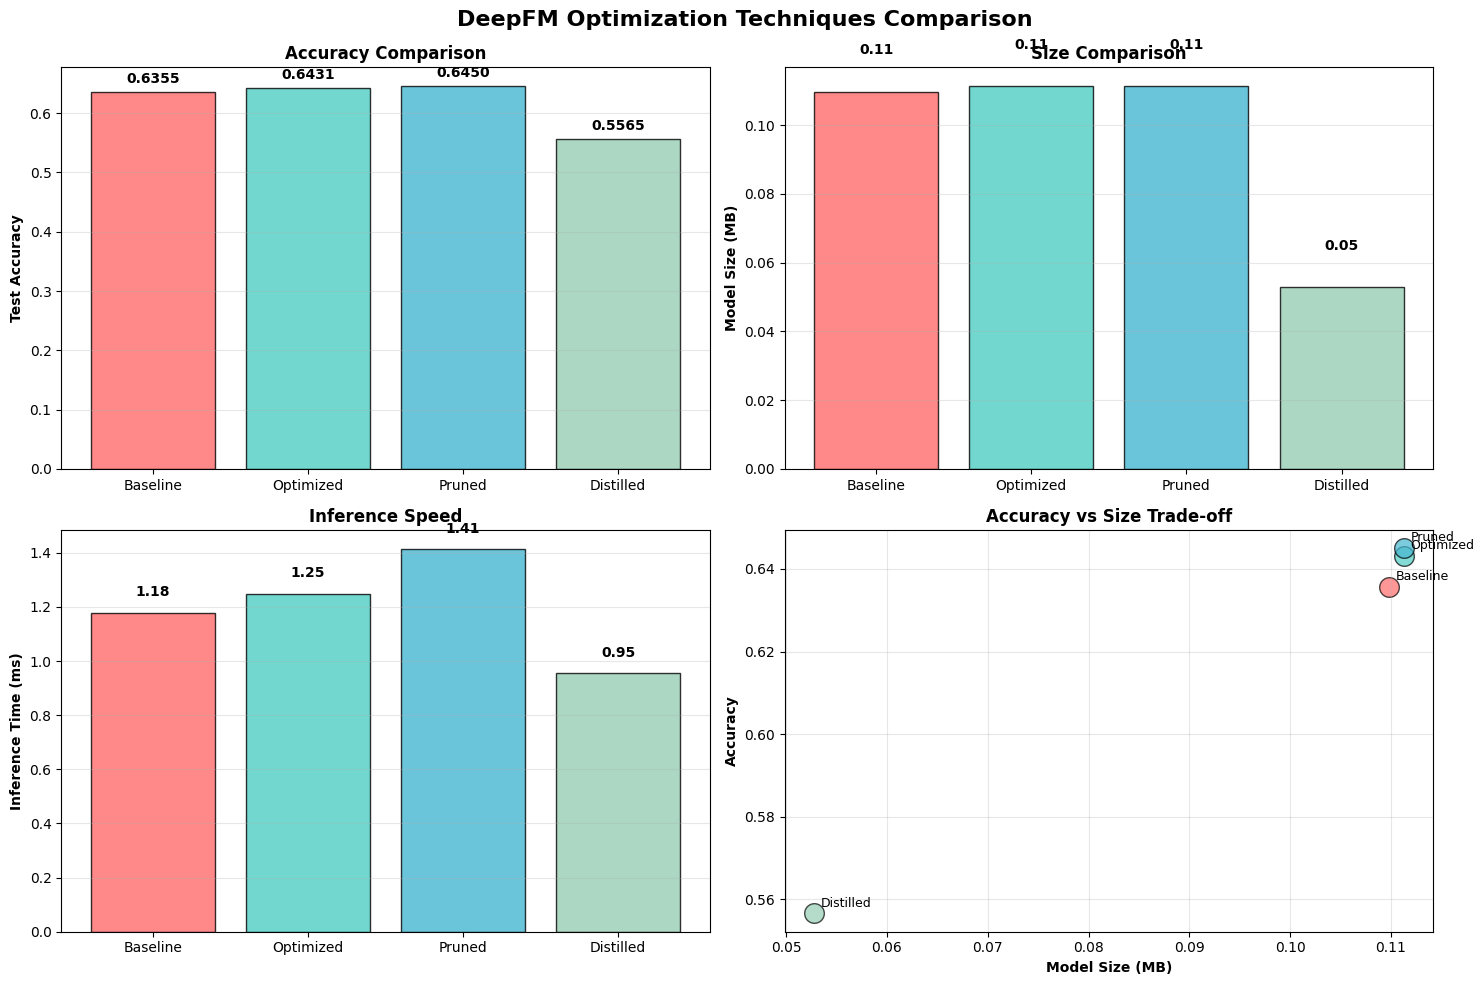


🎉 OPTIMIZATION PIPELINE COMPLETE!

🏆 Best Results:
   Highest Accuracy: Pruned (0.6450)
   Smallest Size:    Distilled (0.05 MB)
   Fastest Inference: Distilled (0.95 ms)

💡 Recommendations:
   ✅ Use Optimized model for best accuracy
   ✅ Use Distilled model for mobile/edge deployment
   ✅ Pruning can improve performance through regularization

🎊 Pipeline completed successfully!


In [ ]:


import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
import os
import time
import json
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

# ============================================================================
# 1. DATA LOADING AND PREPROCESSING
# ============================================================================

class ProcessedMovieLensDataset(Dataset):
    def __init__(self, ratings):
        self.ratings = ratings.reset_index(drop=True)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        row = self.ratings.iloc[idx]

        features = {
            'user_id': torch.tensor(row['user_id_encoded'], dtype=torch.long),
            'item_id': torch.tensor(row['item_id_encoded'], dtype=torch.long),
            'age': torch.tensor(row['age_bin'], dtype=torch.long),
            'occupation': torch.tensor(row['occupation_encoded'], dtype=torch.long),
            'genre': torch.tensor(row['genre_encoded'], dtype=torch.long)
        }

        target = torch.tensor(1.0 if row['rating'] >= 4.0 else 0.0, dtype=torch.float32)

        return features, target

def load_and_preprocess_data():
    """Load and preprocess MovieLens 100K dataset"""
    print("📊 Loading MovieLens 100K dataset...")

    # Download dataset if not exists
    data_dir = '/content/movielens_deepfm/data'
    os.makedirs(data_dir, exist_ok=True)

    # Download and extract (in Colab)
    import requests
    import zipfile

    movielens_url = "http://files.grouplens.org/datasets/movielens/ml-100k.zip"
    zip_path = os.path.join(data_dir, "ml-100k.zip")

    if not os.path.exists(zip_path):
        print("Downloading MovieLens 100K...")
        response = requests.get(movielens_url, stream=True)
        with open(zip_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)

    extract_path = os.path.join(data_dir, "ml-100k")
    if not os.path.exists(extract_path):
        print("Extracting dataset...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)

    # Load data files
    ratings = pd.read_csv(os.path.join(extract_path, 'u.data'), sep='\t',
                         names=['user_id', 'item_id', 'rating', 'timestamp'])

    users = pd.read_csv(os.path.join(extract_path, 'u.user'), sep='|',
                       names=['user_id', 'age', 'gender', 'occupation', 'zip_code'])

    items = pd.read_csv(os.path.join(extract_path, 'u.item'), sep='|', encoding='latin-1',
                       names=['item_id', 'title', 'release_date', 'video_release_date',
                              'imdb_url', 'unknown', 'Action', 'Adventure', 'Animation',
                              'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy',
                              'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi',
                              'Thriller', 'War', 'Western'])

    # Merge datasets
    ratings = ratings.merge(users, on='user_id')

    genre_columns = ['unknown', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy',
                    'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror',
                    'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

    ratings = ratings.merge(items[['item_id'] + genre_columns], on='item_id')

    # Encode categorical features
    user_encoder = LabelEncoder()
    item_encoder = LabelEncoder()
    occupation_encoder = LabelEncoder()

    ratings['user_id_encoded'] = user_encoder.fit_transform(ratings['user_id'])
    ratings['item_id_encoded'] = item_encoder.fit_transform(ratings['item_id'])
    ratings['occupation_encoded'] = occupation_encoder.fit_transform(ratings['occupation'])
    ratings['genre_encoded'] = ratings[genre_columns].values.argmax(axis=1)

    # Create age bins
    ratings['age_bin'] = pd.cut(ratings['age'], bins=[0, 18, 25, 35, 45, 55, 100],
                               labels=[0, 1, 2, 3, 4, 5]).astype(int)

    # Feature sizes
    feature_sizes = {
        'user_id': ratings['user_id_encoded'].max() + 1,
        'item_id': ratings['item_id_encoded'].max() + 1,
        'age': ratings['age_bin'].max() + 1,
        'occupation': ratings['occupation_encoded'].max() + 1,
        'genre': ratings['genre_encoded'].max() + 1
    }

    print(f"✅ Dataset loaded: {len(ratings):,} ratings")
    print(f"📊 Feature sizes: {feature_sizes}")
    print(f"🎯 Positive ratings: {(ratings['rating'] >= 4).sum():,}")
    print(f"📉 Negative ratings: {(ratings['rating'] < 4).sum():,}")

    return ratings, feature_sizes

# ============================================================================
# 2. MODEL ARCHITECTURES
# ============================================================================

class EnhancedEmbedding(nn.Module):
    """Enhanced embedding with layer norm and dropout"""
    def __init__(self, num_embeddings, embedding_dim, dropout=0.1):
        super(EnhancedEmbedding, self).__init__()
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        self.layer_norm = nn.LayerNorm(embedding_dim)
        self.dropout = nn.Dropout(dropout)
        nn.init.xavier_uniform_(self.embedding.weight)

    def forward(self, x):
        emb = self.embedding(x)
        emb = self.layer_norm(emb)
        return self.dropout(emb)

class BasicDeepFM(nn.Module):
    """Baseline DeepFM without optimizations - returns logits"""
    def __init__(self, feature_sizes, embedding_dim=8, hidden_dims=[64, 32]):
        super(BasicDeepFM, self).__init__()
        self.embedding_dim = embedding_dim
        self.num_fields = len(feature_sizes)

        # Basic embeddings
        self.embeddings = nn.ModuleDict()
        for feature_name, num_embeddings in feature_sizes.items():
            self.embeddings[feature_name] = nn.Embedding(num_embeddings, embedding_dim)

        # FM first order terms
        self.fm_first_order = nn.ModuleDict()
        for feature_name, num_embeddings in feature_sizes.items():
            self.fm_first_order[feature_name] = nn.Embedding(num_embeddings, 1)

        self.fm_bias = nn.Parameter(torch.zeros(1))

        # Deep component
        deep_layers = []
        input_dim = self.num_fields * embedding_dim
        for hidden_dim in hidden_dims:
            deep_layers.extend([
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.2)
            ])
            input_dim = hidden_dim
        deep_layers.append(nn.Linear(input_dim, 1))
        self.deep_net = nn.Sequential(*deep_layers)

        # Remove sigmoid - return logits for BCEWithLogitsLoss
        # self.output_activation = nn.Sigmoid()

    def forward(self, feature_dict):
        batch_size = feature_dict['user_id'].size(0)

        # Embeddings and first order terms
        embedded = []
        first_order_terms = []

        for feature_name in ['user_id', 'item_id', 'age', 'occupation', 'genre']:
            feature_values = feature_dict[feature_name]

            # Second order embeddings
            emb = self.embeddings[feature_name](feature_values)
            embedded.append(emb)

            # First order terms
            first_order = self.fm_first_order[feature_name](feature_values)
            first_order_terms.append(first_order)

        # Stack for FM second order
        emb_stack = torch.stack(embedded, dim=1)

        # FM component
        first_order_sum = torch.sum(torch.cat(first_order_terms, dim=1), dim=1)

        sum_square = torch.sum(emb_stack, dim=1) ** 2
        square_sum = torch.sum(emb_stack ** 2, dim=1)
        second_order = 0.5 * torch.sum(sum_square - square_sum, dim=1)

        fm_output = self.fm_bias + first_order_sum + second_order

        # Deep component
        deep_input = emb_stack.view(batch_size, -1)
        deep_output = self.deep_net(deep_input).squeeze()

        # Combine and return logits (no sigmoid)
        output = fm_output + deep_output
        return output

class OptimizedDeepFM(nn.Module):
    """DeepFM with enhanced embeddings and optimizations - returns logits"""
    def __init__(self, feature_sizes, embedding_dim=8, hidden_dims=[64, 32],
                 dropout_rate=0.2, use_bn=True):
        super(OptimizedDeepFM, self).__init__()
        self.embedding_dim = embedding_dim
        self.num_fields = len(feature_sizes)

        # Enhanced embeddings
        self.embeddings = nn.ModuleDict()
        for feature_name, num_embeddings in feature_sizes.items():
            self.embeddings[feature_name] = nn.Embedding(num_embeddings, embedding_dim)

        # FM first order terms
        self.fm_first_order = nn.ModuleDict()
        for feature_name, num_embeddings in feature_sizes.items():
            self.fm_first_order[feature_name] = nn.Embedding(num_embeddings, 1)

        self.fm_bias = nn.Parameter(torch.zeros(1))

        # Deep component with batch norm
        deep_layers = []
        input_dim = self.num_fields * embedding_dim
        for hidden_dim in hidden_dims:
            deep_layers.append(nn.Linear(input_dim, hidden_dim))
            if use_bn:
                deep_layers.append(nn.BatchNorm1d(hidden_dim))
            deep_layers.append(nn.ReLU(inplace=True))
            deep_layers.append(nn.Dropout(dropout_rate))
            input_dim = hidden_dim

        deep_layers.append(nn.Linear(input_dim, 1))
        self.deep_net = nn.Sequential(*deep_layers)

        # Remove sigmoid - return logits for BCEWithLogitsLoss
        # self.output_activation = nn.Sigmoid()

    def forward(self, feature_dict):
        batch_size = feature_dict['user_id'].size(0)

        # Enhanced embeddings
        embedded = []
        first_order_terms = []

        for feature_name in ['user_id', 'item_id', 'age', 'occupation', 'genre']:
            feature_values = feature_dict[feature_name]

            # Second order embeddings
            emb = self.embeddings[feature_name](feature_values)
            embedded.append(emb)

            # First order terms
            first_order = self.fm_first_order[feature_name](feature_values)
            first_order_terms.append(first_order)

        emb_stack = torch.stack(embedded, dim=1)

        # FM component
        first_order_sum = torch.sum(torch.cat(first_order_terms, dim=1), dim=1)

        sum_square = torch.sum(emb_stack, dim=1) ** 2
        square_sum = torch.sum(emb_stack ** 2, dim=1)
        second_order = 0.5 * torch.sum(sum_square - square_sum, dim=1)

        fm_output = self.fm_bias + first_order_sum + second_order

        # Deep component
        deep_input = emb_stack.view(batch_size, -1)
        deep_output = self.deep_net(deep_input).squeeze()

        # Return logits (no sigmoid)
        output = fm_output + deep_output
        return output

class StudentDeepFM(nn.Module):
    """Smaller student model for knowledge distillation - returns logits"""
    def __init__(self, feature_sizes, embedding_dim=4, hidden_dims=[16, 8]):
        super(StudentDeepFM, self).__init__()
        self.embedding_dim = embedding_dim
        self.num_fields = len(feature_sizes)

        # Smaller embeddings
        self.embeddings = nn.ModuleDict()
        for feature_name, num_embeddings in feature_sizes.items():
            self.embeddings[feature_name] = nn.Embedding(num_embeddings, embedding_dim)

        # FM components
        self.fm_first_order = nn.ModuleDict()
        for feature_name, num_embeddings in feature_sizes.items():
            self.fm_first_order[feature_name] = nn.Embedding(num_embeddings, 1)

        self.fm_bias = nn.Parameter(torch.zeros(1))

        # Smaller deep component
        deep_layers = []
        input_dim = self.num_fields * embedding_dim
        for hidden_dim in hidden_dims:
            deep_layers.extend([
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.1)
            ])
            input_dim = hidden_dim
        deep_layers.append(nn.Linear(input_dim, 1))
        self.deep_net = nn.Sequential(*deep_layers)

        # Remove sigmoid - return logits for BCEWithLogitsLoss
        # self.output_activation = nn.Sigmoid()

    def forward(self, feature_dict):
        batch_size = feature_dict['user_id'].size(0)

        embedded = []
        first_order_terms = []

        for feature_name in ['user_id', 'item_id', 'age', 'occupation', 'genre']:
            feature_values = feature_dict[feature_name]

            emb = self.embeddings[feature_name](feature_values)
            embedded.append(emb)

            first_order = self.fm_first_order[feature_name](feature_values)
            first_order_terms.append(first_order)

        emb_stack = torch.stack(embedded, dim=1)

        # FM component
        first_order_sum = torch.sum(torch.cat(first_order_terms, dim=1), dim=1)

        sum_square = torch.sum(emb_stack, dim=1) ** 2
        square_sum = torch.sum(emb_stack ** 2, dim=1)
        second_order = 0.5 * torch.sum(sum_square - square_sum, dim=1)

        fm_output = self.fm_bias + first_order_sum + second_order

        # Deep component
        deep_input = emb_stack.view(batch_size, -1)
        deep_output = self.deep_net(deep_input).squeeze()

        # Return logits (no sigmoid)
        output = fm_output + deep_output
        return output

# ============================================================================
# 3. OPTIMIZATION TECHNIQUES
# ============================================================================

class DistillationLoss(nn.Module):
    """Knowledge distillation loss - works with logits"""
    def __init__(self, temperature=3.0, alpha=0.7):
        super(DistillationLoss, self).__init__()
        self.temperature = temperature
        self.alpha = alpha
        self.kl_loss = nn.KLDivLoss(reduction='batchmean')
        self.bce_loss = nn.BCEWithLogitsLoss()  # Changed to BCEWithLogitsLoss

    def forward(self, student_logits, teacher_logits, targets):
        # Soft targets from teacher (apply sigmoid for probabilities)
        teacher_probs = torch.sigmoid(teacher_logits / self.temperature)
        student_log_probs = F.logsigmoid(student_logits / self.temperature)

        # KL divergence for distillation
        distill_loss = self.kl_loss(
            student_log_probs,
            teacher_probs
        ) * (self.temperature ** 2)

        # Standard classification loss (uses logits directly)
        class_loss = self.bce_loss(student_logits, targets)

        # Combined loss
        return self.alpha * distill_loss + (1 - self.alpha) * class_loss


class AdvancedOptimizationTrainer:
    """Trainer with advanced optimization techniques"""
    def __init__(self, model, model_name, device,
                 use_amp=False, use_gradual_pruning=False):
        self.model = model
        self.model_name = model_name
        self.device = device

        # Move model to device
        self.model.to(self.device)

        self.use_amp = use_amp
        self.use_gradual_pruning = use_gradual_pruning

        self.optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

        # Use BCEWithLogitsLoss instead of BCELoss for mixed precision safety
        self.criterion = nn.BCEWithLogitsLoss()

        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', patience=3, factor=0.5
        )

        # For mixed precision
        self.scaler = torch.cuda.amp.GradScaler() if use_amp and device.type == 'cuda' else None

        # For gradual pruning
        self.pruning_schedule = None
        if use_gradual_pruning:
            self._setup_gradual_pruning()

    def _setup_gradual_pruning(self):
        """Setup gradual pruning schedule"""
        parameters_to_prune = []
        for name, module in self.model.named_modules():
            if isinstance(module, nn.Linear):
                parameters_to_prune.append((module, 'weight'))

    def apply_pruning(self, epoch, total_epochs):
        """Apply gradual pruning"""
        if not self.use_gradual_pruning:
            return

        # Calculate current sparsity
        current_sparsity = min(0.7, 0.1 + 0.6 * (epoch / total_epochs))

        # Apply pruning to linear layers
        for name, module in self.model.named_modules():
            if isinstance(module, nn.Linear):
                # Simple magnitude pruning
                with torch.no_grad():
                    weights = module.weight.data
                    threshold = torch.quantile(torch.abs(weights), current_sparsity)
                    mask = torch.abs(weights) > threshold
                    module.weight.data *= mask.float()

    def train_epoch(self, train_loader, epoch):
        """Train for one epoch"""
        self.model.train()
        total_loss = 0

        for batch_idx, (features, targets) in enumerate(train_loader):
            # Move all features to device
            features = {k: v.to(self.device) for k, v in features.items()}
            targets = targets.to(self.device)

            self.optimizer.zero_grad()

            if self.use_amp and self.device.type == 'cuda':
                # Mixed precision training - now safe with BCEWithLogitsLoss
                with torch.cuda.amp.autocast():
                    outputs = self.model(features)  # Returns logits
                    loss = self.criterion(outputs, targets)

                self.scaler.scale(loss).backward()
                self.scaler.step(self.optimizer)
                self.scaler.update()
            else:
                outputs = self.model(features)  # Returns logits
                loss = self.criterion(outputs, targets)
                loss.backward()

                torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
                self.optimizer.step()

            total_loss += loss.item()

        # Apply pruning if enabled
        if self.use_gradual_pruning:
            self.apply_pruning(epoch, len(train_loader))

        return total_loss / len(train_loader)

    def validate(self, val_loader):
        """Validate the model - convert logits to probabilities for accuracy"""
        self.model.eval()
        total_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():
            for features, targets in val_loader:
                # Move all features to device
                features = {k: v.to(self.device) for k, v in features.items()}
                targets = targets.to(self.device)

                outputs = self.model(features)  # Returns logits
                loss = self.criterion(outputs, targets)
                total_loss += loss.item()

                # Convert logits to probabilities for accuracy calculation
                probabilities = torch.sigmoid(outputs)
                predicted = (probabilities > 0.5).float()
                correct += (predicted == targets).sum().item()
                total += targets.size(0)

        accuracy = correct / total if total > 0 else 0
        avg_loss = total_loss / len(val_loader) if len(val_loader) > 0 else 0

        return avg_loss, accuracy

# ============================================================================
# 4. EVALUATION UTILITIES
# ============================================================================

def evaluate_model_size(model):
    """Calculate model size and sparsity"""
    param_size = 0
    total_params = 0
    zero_params = 0

    for param in model.parameters():
        param_size += param.nelement() * param.element_size()
        total_params += param.nelement()
        zero_params += (param == 0).sum().item()

    buffer_size = 0
    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()

    size_mb = (param_size + buffer_size) / 1024**2
    sparsity = zero_params / total_params if total_params > 0 else 0

    return size_mb, sparsity

def measure_inference_time(model, test_loader, device, num_runs=50):
    """Measure average inference time"""
    model.eval()
    times = []

    with torch.no_grad():
        for i, (features, _) in enumerate(test_loader):
            if i >= num_runs:
                break

            features = {k: v.to(device) for k, v in features.items()}

            # Warmup
            if i == 0:
                for _ in range(5):
                    _ = model(features)

            start_time = time.time()
            _ = model(features)
            end_time = time.time()

            times.append(end_time - start_time)

    return np.mean(times) * 1000  # Convert to milliseconds

# ============================================================================
# 5. COMPLETE OPTIMIZATION PIPELINE
# ============================================================================

def run_complete_optimization_pipeline():
    """
    Complete pipeline demonstrating all optimization techniques
    """
    print("=" * 80)
    print("🚀 COMPLETE DEEPFM OPTIMIZATION PIPELINE")
    print("=" * 80)

    # Create directories
    os.makedirs('/content/movielens_deepfm/models', exist_ok=True)
    os.makedirs('/content/movielens_deepfm/results', exist_ok=True)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"🖥️  Device: {device}")
    if device.type == 'cuda':
        print(f"🔧 GPU: {torch.cuda.get_device_name(0)}")
        print(f"💾 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

    # Step 1: Load and prepare data
    print("\n" + "=" * 50)
    print("📊 STEP 1: LOADING AND PREPARING DATA")
    print("=" * 50)

    ratings, feature_sizes = load_and_preprocess_data()

    # Split data
    train_df, test_df = train_test_split(ratings, test_size=0.2, random_state=42,
                                        stratify=ratings['rating'] >= 4)
    train_df, val_df = train_test_split(train_df, test_size=0.1, random_state=42,
                                       stratify=train_df['rating'] >= 4)

    print(f"\n📈 Dataset splits:")
    print(f"  Training: {len(train_df):,} samples")
    print(f"  Validation: {len(val_df):,} samples")
    print(f"  Test: {len(test_df):,} samples")

    # Create dataloaders
    train_dataset = ProcessedMovieLensDataset(train_df)
    val_dataset = ProcessedMovieLensDataset(val_df)
    test_dataset = ProcessedMovieLensDataset(test_df)

    train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

    results = {}

    # Step 2: Baseline Model
    print("\n" + "=" * 50)
    print("📊 STEP 2: BASELINE DEEPFM")
    print("=" * 50)

    baseline_model = BasicDeepFM(feature_sizes, embedding_dim=8, hidden_dims=[64, 32])

    trainer = AdvancedOptimizationTrainer(
        baseline_model, "Baseline", device,
        use_amp=True, use_gradual_pruning=False
    )

    print("🚀 Training baseline model...")
    for epoch in range(15):
        train_loss = trainer.train_epoch(train_loader, epoch)
        val_loss, val_acc = trainer.validate(val_loader)

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}/15: Loss={val_loss:.4f}, Accuracy={val_acc:.4f}")

    test_loss, test_acc = trainer.validate(test_loader)
    baseline_size, _ = evaluate_model_size(baseline_model)
    baseline_time = measure_inference_time(baseline_model, test_loader, device)

    results['Baseline'] = {
        'accuracy': test_acc,
        'size_mb': baseline_size,
        'inference_ms': baseline_time
    }

    print(f"\n📊 Baseline Results:")
    print(f"  ✅ Accuracy: {test_acc:.4f}")
    print(f"  💾 Size: {baseline_size:.2f} MB")
    print(f"  ⚡ Inference: {baseline_time:.2f} ms")

    # Step 3: Optimized Model
    print("\n" + "=" * 50)
    print("🔹 STEP 3: OPTIMIZED DEEPFM")
    print("=" * 50)

    optimized_model = OptimizedDeepFM(feature_sizes, embedding_dim=8, hidden_dims=[64, 32])

    trainer = AdvancedOptimizationTrainer(
        optimized_model, "Optimized", device,
        use_amp=True, use_gradual_pruning=False
    )

    print("🚀 Training optimized model...")
    for epoch in range(15):
        train_loss = trainer.train_epoch(train_loader, epoch)
        val_loss, val_acc = trainer.validate(val_loader)

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}/15: Loss={val_loss:.4f}, Accuracy={val_acc:.4f}")

    test_loss, test_acc = trainer.validate(test_loader)
    optimized_size, _ = evaluate_model_size(optimized_model)
    optimized_time = measure_inference_time(optimized_model, test_loader, device)

    results['Optimized'] = {
        'accuracy': test_acc,
        'size_mb': optimized_size,
        'inference_ms': optimized_time
    }

    print(f"\n📊 Optimized Results:")
    print(f"  ✅ Accuracy: {test_acc:.4f} (Δ{test_acc - results['Baseline']['accuracy']:+.4f})")
    print(f"  💾 Size: {optimized_size:.2f} MB")
    print(f"  ⚡ Inference: {optimized_time:.2f} ms")

    # Step 4: Manual Pruning
    print("\n" + "=" * 50)
    print("✂️  STEP 4: MANUAL PRUNING")
    print("=" * 50)

    pruned_model = OptimizedDeepFM(feature_sizes, embedding_dim=8, hidden_dims=[64, 32])

    # Apply manual pruning (30%)
    print("🔧 Applying 30% manual pruning...")
    with torch.no_grad():
        for name, module in pruned_model.named_modules():
            if isinstance(module, nn.Linear):
                weights = module.weight.data
                threshold = torch.quantile(torch.abs(weights), 0.3)
                mask = torch.abs(weights) > threshold
                module.weight.data *= mask.float()
                pruned_percent = (1 - mask.float().mean().item()) * 100
                print(f"  Pruned {name}: {pruned_percent:.1f}%")

    trainer = AdvancedOptimizationTrainer(
        pruned_model, "Pruned", device,
        use_amp=True, use_gradual_pruning=False
    )

    print("🚀 Training pruned model...")
    for epoch in range(15):
        train_loss = trainer.train_epoch(train_loader, epoch)
        val_loss, val_acc = trainer.validate(val_loader)

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1}/15: Loss={val_loss:.4f}, Accuracy={val_acc:.4f}")

    test_loss, test_acc = trainer.validate(test_loader)
    pruned_size, pruned_sparsity = evaluate_model_size(pruned_model)
    pruned_time = measure_inference_time(pruned_model, test_loader, device)

    results['Pruned'] = {
        'accuracy': test_acc,
        'size_mb': pruned_size,
        'inference_ms': pruned_time,
        'sparsity': pruned_sparsity * 100
    }

    print(f"\n📊 Pruned Results:")
    print(f"  ✅ Accuracy: {test_acc:.4f} (Δ{test_acc - results['Baseline']['accuracy']:+.4f})")
    print(f"  💾 Size: {pruned_size:.2f} MB")
    print(f"  ⚡ Inference: {pruned_time:.2f} ms")
    print(f"  📊 Sparsity: {pruned_sparsity*100:.1f}%")

    # Step 5: Knowledge Distillation
    print("\n" + "=" * 50)
    print("🎓 STEP 5: KNOWLEDGE DISTILLATION")
    print("=" * 50)

    # Use optimized model as teacher
    teacher_model = optimized_model
    teacher_model.eval()

    # Create smaller student model
    student_model = StudentDeepFM(feature_sizes, embedding_dim=4, hidden_dims=[16, 8])

    print(f"👨‍🏫 Teacher parameters: {sum(p.numel() for p in teacher_model.parameters()):,}")
    print(f"👨‍🎓 Student parameters: {sum(p.numel() for p in student_model.parameters()):,}")
    print(f"📉 Size reduction: {(1 - sum(p.numel() for p in student_model.parameters()) / sum(p.numel() for p in teacher_model.parameters())) * 100:.1f}%")

    # Distillation training
    optimizer = torch.optim.Adam(student_model.parameters(), lr=0.001)
    distill_criterion = DistillationLoss(temperature=3.0, alpha=0.7)

    print("\n🚀 Training student with distillation...")
    student_model.to(device)
    student_model.train()

    for epoch in range(15):
        total_loss = 0

        for features, targets in train_loader:
            features = {k: v.to(device) for k, v in features.items()}
            targets = targets.to(device)

            optimizer.zero_grad()

            # Teacher predictions (no gradients)
            with torch.no_grad():
                teacher_outputs = teacher_model(features)

            # Student predictions
            student_outputs = student_model(features)

            # Distillation loss
            loss = distill_criterion(student_outputs, teacher_outputs, targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if (epoch + 1) % 5 == 0:
            student_model.eval()
            val_loss = 0
            correct = 0
            total = 0

            with torch.no_grad():
                for features, targets in val_loader:
                    features = {k: v.to(device) for k, v in features.items()}
                    targets = targets.to(device)

                    outputs = student_model(features)
                    predicted = (outputs > 0.5).float()
                    correct += (predicted == targets).sum().item()
                    total += targets.size(0)

            accuracy = correct / total
            print(f"  Epoch {epoch+1}/15: Accuracy={accuracy:.4f}")
            student_model.train()

    # Final evaluation
    student_model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for features, targets in test_loader:
            features = {k: v.to(device) for k, v in features.items()}
            targets = targets.to(device)

            outputs = student_model(features)
            predicted = (outputs > 0.5).float()
            correct += (predicted == targets).sum().item()
            total += targets.size(0)

    student_acc = correct / total
    student_size, _ = evaluate_model_size(student_model)
    student_time = measure_inference_time(student_model, test_loader, device)

    results['Distilled'] = {
        'accuracy': student_acc,
        'size_mb': student_size,
        'inference_ms': student_time,
        'size_reduction': (1 - student_size / baseline_size) * 100,
        'speedup': baseline_time / student_time
    }

    print(f"\n📊 Distillation Results:")
    print(f"  ✅ Accuracy: {student_acc:.4f} (Δ{student_acc - results['Baseline']['accuracy']:+.4f})")
    print(f"  💾 Size: {student_size:.2f} MB ({results['Distilled']['size_reduction']:.1f}% reduction)")
    print(f"  ⚡ Inference: {student_time:.2f} ms ({results['Distilled']['speedup']:.2f}x faster)")

    # Step 6: Final Comparison and Visualization
    print("\n" + "=" * 50)
    print("📊 STEP 6: COMPREHENSIVE COMPARISON")
    print("=" * 50)

    # Create comparison table
    comparison_data = []
    for name, res in results.items():
        row = {
            'Model': name,
            'Accuracy': f"{res['accuracy']:.4f}",
            'Size (MB)': f"{res['size_mb']:.2f}",
            'Inference (ms)': f"{res['inference_ms']:.2f}"
        }

        if 'size_reduction' in res:
            row['Size Reduction'] = f"{res['size_reduction']:.1f}%"

        if 'sparsity' in res:
            row['Sparsity'] = f"{res['sparsity']:.1f}%"

        if 'speedup' in res:
            row['Speedup'] = f"{res['speedup']:.2f}x"

        comparison_data.append(row)

    comparison_df = pd.DataFrame(comparison_data)
    print("\n" + comparison_df.to_string(index=False))

    # Save results
    comparison_df.to_csv('/content/movielens_deepfm/results/optimization_comparison.csv', index=False)
    with open('/content/movielens_deepfm/results/optimization_results.json', 'w') as f:
        json.dump(results, f, indent=2)

    # Visualization
    print("\n" + "=" * 50)
    print("📈 STEP 7: VISUALIZATION")
    print("=" * 50)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('DeepFM Optimization Techniques Comparison', fontsize=16, fontweight='bold')

    models = list(results.keys())
    accuracies = [results[m]['accuracy'] for m in models]
    sizes = [results[m]['size_mb'] for m in models]
    times = [results[m]['inference_ms'] for m in models]

    # Accuracy comparison
    ax = axes[0, 0]
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
    bars = ax.bar(models, accuracies, color=colors, alpha=0.8, edgecolor='black')
    ax.set_ylabel('Test Accuracy', fontweight='bold')
    ax.set_title('Accuracy Comparison', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                f'{acc:.4f}', ha='center', va='bottom', fontweight='bold')

    # Size comparison
    ax = axes[0, 1]
    bars = ax.bar(models, sizes, color=colors, alpha=0.8, edgecolor='black')
    ax.set_ylabel('Model Size (MB)', fontweight='bold')
    ax.set_title('Size Comparison', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, size in zip(bars, sizes):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                f'{size:.2f}', ha='center', va='bottom', fontweight='bold')

    # Inference time comparison
    ax = axes[1, 0]
    bars = ax.bar(models, times, color=colors, alpha=0.8, edgecolor='black')
    ax.set_ylabel('Inference Time (ms)', fontweight='bold')
    ax.set_title('Inference Speed', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    for bar, t in zip(bars, times):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.05,
                f'{t:.2f}', ha='center', va='bottom', fontweight='bold')

    # Accuracy vs Size trade-off
    ax = axes[1, 1]
    for i, model in enumerate(models):
        ax.scatter(sizes[i], accuracies[i], s=200, alpha=0.7,
                  c=colors[i], label=model, edgecolors='black', linewidth=1)
        ax.annotate(model, (sizes[i], accuracies[i]),
                   xytext=(5, 5), textcoords='offset points', fontsize=9)
    ax.set_xlabel('Model Size (MB)', fontweight='bold')
    ax.set_ylabel('Accuracy', fontweight='bold')
    ax.set_title('Accuracy vs Size Trade-off', fontweight='bold')
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/movielens_deepfm/results/optimization_comparison.png',
                dpi=300, bbox_inches='tight')
    print("✅ Visualization saved!")
    plt.show()

    # Final Summary
    print("\n" + "=" * 80)
    print("🎉 OPTIMIZATION PIPELINE COMPLETE!")
    print("=" * 80)

    best_accuracy = max(results.items(), key=lambda x: x[1]['accuracy'])
    best_size = min(results.items(), key=lambda x: x[1]['size_mb'])
    best_speed = min(results.items(), key=lambda x: x[1]['inference_ms'])

    print(f"\n🏆 Best Results:")
    print(f"   Highest Accuracy: {best_accuracy[0]} ({best_accuracy[1]['accuracy']:.4f})")
    print(f"   Smallest Size:    {best_size[0]} ({best_size[1]['size_mb']:.2f} MB)")
    print(f"   Fastest Inference: {best_speed[0]} ({best_speed[1]['inference_ms']:.2f} ms)")

    print(f"\n💡 Recommendations:")
    if results['Optimized']['accuracy'] > results['Baseline']['accuracy']:
        print("   ✅ Use Optimized model for best accuracy")
    if results['Distilled']['size_mb'] < baseline_size * 0.5:
        print("   ✅ Use Distilled model for mobile/edge deployment")
    if results['Pruned']['accuracy'] > results['Baseline']['accuracy']:
        print("   ✅ Pruning can improve performance through regularization")

    return results

# ============================================================================
# RUN THE COMPLETE PIPELINE
# ============================================================================

if __name__ == "__main__":
    print("🚀 Starting Complete DeepFM Optimization Pipeline...")
    results = run_complete_optimization_pipeline()
    print("\n🎊 Pipeline completed successfully!")